In [ ]:
# This project addresses the challenge of how to use data to manage cybersecurity services as operational services, rather than isolated technical functions.

Saved: incidents_enriched.csv

=== KPI Summary (minutes) ===


,count,mean_min,median_min,p90_min,p95_min,max_min
Detect → Resolution (MTTR),12.0,205.08,194.5,350.0,364.95,371.0
Detect → Triage,12.0,22.25,22.0,37.7,40.25,43.0
Escalation → Resolution,6.0,205.00,177.0,305.0,314.00,323.0
Triage → Escalation,6.0,50.33,56.5,72.5,74.75,77.0
Triage → Resolution,12.0,182.83,168.0,337.8,350.60,355.0



=== Funnel ===
Total: 12
Triaged: 12 (100.0%)
Escalated: 6 (50.0%)
Resolved: 12 (100.0%)

=== SLA Breach Rates ===
t_detect_to_triage_min: 66.7% breached (target 15 min)
t_triage_to_resolution_min: 25.0% breached (target 240 min)
t_detect_to_resolution_min: 8.3% breached (target 360 min)


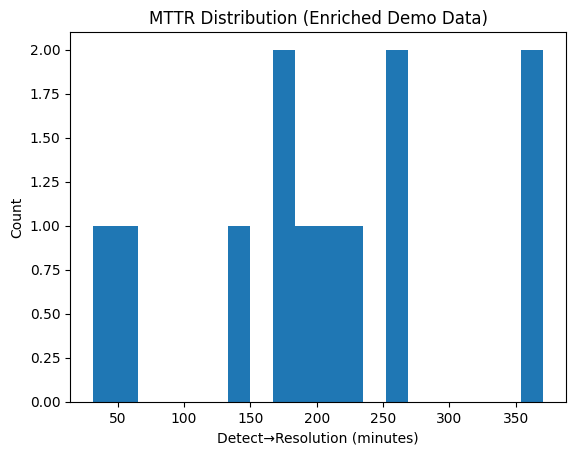


=== Enriched data preview ===


,incident_id,detected_at,triaged_at,escalated_at,resolved_at,severity,team,category,city
0,INC-2025-01,2025-01-05 09:12:00+00:00,2025-01-05 09:17:00+00:00,2025-01-05 10:25:00+00:00,2025-01-05 15:12:00+00:00,Low,SOC Tier 2,Data Exfiltration,London
1,INC-2025-02,2025-02-11 14:02:00+00:00,2025-02-11 14:37:00+00:00,NaT,2025-02-11 17:07:00+00:00,Medium,SOC Tier 2,Phishing,London
2,INC-2025-03,2025-03-18 08:47:00+00:00,2025-03-18 09:17:00+00:00,2025-03-18 10:24:00+00:00,2025-03-18 13:06:00+00:00,Low,SOC Tier 2,Phishing,London
3,INC-2025-04,2025-04-07 15:35:00+00:00,2025-04-07 15:55:00+00:00,NaT,2025-04-07 17:52:00+00:00,High,SOC Tier 2,Phishing,London
4,INC-2025-05,2025-05-22 10:10:00+00:00,2025-05-22 10:30:00+00:00,NaT,2025-05-22 11:08:00+00:00,Medium,SOC Tier 2,Data Exfiltration,London


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

raw = pd.read_csv("Incidents1.csv")
raw["detected_at"] = pd.to_datetime(raw["detected_at"], utc=True, errors="coerce")

rng = np.random.default_rng(42)
df = raw.copy()

n = len(df)

detect_to_triage = rng.integers(2, 45, size=n)
triage_to_escalate = rng.integers(10, 90, size=n)
escalate_to_resolve = rng.integers(30, 360, size=n)
triage_to_resolve_no_escal = rng.integers(10, 180, size=n)

df["triaged_at"] = df["detected_at"] + pd.to_timedelta(detect_to_triage, unit="m")

# Escalation (some missing)
not_escalated_mask = rng.random(n) < 0.40
df["escalated_at"] = df["triaged_at"] + pd.to_timedelta(triage_to_escalate, unit="m")
df.loc[not_escalated_mask, "escalated_at"] = pd.NaT

# Resolution: start with "resolved from triage" then overwrite escalated ones
df["resolved_at"] = df["triaged_at"] + pd.to_timedelta(triage_to_resolve_no_escal, unit="m")
escalated_mask = df["escalated_at"].notna()
df.loc[escalated_mask, "resolved_at"] = df.loc[escalated_mask, "escalated_at"] + pd.to_timedelta(
    escalate_to_resolve[escalated_mask.to_numpy()], unit="m"
)

# Metadata
severities = np.array(["Low", "Medium", "High", "Critical"])
categories = np.array(["Phishing", "Malware", "Ransomware", "Data Exfiltration", "False Alert"])
teams = np.array(["SOC Tier 1", "SOC Tier 2", "IR Team"])

df["severity"] = rng.choice(severities, size=n, p=[0.35, 0.30, 0.25, 0.10])
df["category"] = rng.choice(categories, size=n, p=[0.30, 0.25, 0.10, 0.15, 0.20])
df["team"] = rng.choice(teams, size=n, p=[0.45, 0.35, 0.20])
df["is_false_positive"] = (df["category"] == "False Alert") | ((df["severity"] == "Low") & (rng.random(n) < 0.25))

out_path = "incidents_enriched.csv"   # saves in the same folder as your notebook
df.to_csv(out_path, index=False)
print("Saved:", out_path)


# ---- Run KPI analysis using your logic ----
df = pd.read_csv(out_path)

ts_cols = ["detected_at", "triaged_at", "escalated_at", "resolved_at"]
for c in ts_cols:
    df[c] = pd.to_datetime(df[c], utc=True, errors="coerce")

df = df.dropna(subset=["incident_id", "detected_at", "resolved_at"])

df["t_detect_to_triage_min"] = (df["triaged_at"] - df["detected_at"]).dt.total_seconds() / 60
df["t_triage_to_escalation_min"] = (df["escalated_at"] - df["triaged_at"]).dt.total_seconds() / 60
df["t_escalation_to_resolution_min"] = (df["resolved_at"] - df["escalated_at"]).dt.total_seconds() / 60
df["t_triage_to_resolution_min"] = (df["resolved_at"] - df["triaged_at"]).dt.total_seconds() / 60
df["t_detect_to_resolution_min"] = (df["resolved_at"] - df["detected_at"]).dt.total_seconds() / 60

df.loc[df["escalated_at"].isna(), ["t_triage_to_escalation_min", "t_escalation_to_resolution_min"]] = np.nan

dur_cols = [c for c in df.columns if c.startswith("t_") and c.endswith("_min")]
for c in dur_cols:
    df.loc[df[c] < 0, c] = np.nan

def summarize(series: pd.Series) -> dict:
    s = series.dropna()
    if s.empty:
        return {"count": 0}
    return {
        "count": int(s.shape[0]),
        "mean_min": float(s.mean()),
        "median_min": float(s.median()),
        "p90_min": float(s.quantile(0.90)),
        "p95_min": float(s.quantile(0.95)),
        "max_min": float(s.max()),
    }

kpis = {
    "Detect → Triage": summarize(df["t_detect_to_triage_min"]),
    "Triage → Escalation": summarize(df["t_triage_to_escalation_min"]),
    "Escalation → Resolution": summarize(df["t_escalation_to_resolution_min"]),
    "Triage → Resolution": summarize(df["t_triage_to_resolution_min"]),
    "Detect → Resolution (MTTR)": summarize(df["t_detect_to_resolution_min"]),
}
kpi_table = pd.DataFrame(kpis).T.sort_index()

print("\n=== KPI Summary (minutes) ===")
display(kpi_table.round(2))

total = len(df)
triaged = df["triaged_at"].notna().sum()
escalated = df["escalated_at"].notna().sum()
resolved = df["resolved_at"].notna().sum()

print("\n=== Funnel ===")
print(f"Total: {total}")
print(f"Triaged: {triaged} ({triaged/total:.1%})")
print(f"Escalated: {escalated} ({escalated/total:.1%})")
print(f"Resolved: {resolved} ({resolved/total:.1%})")

# SLA breach example (same thresholds)
SLA = {
    "t_detect_to_triage_min": 15,
    "t_triage_to_resolution_min": 240,
    "t_detect_to_resolution_min": 360,
}
for metric, target in SLA.items():
    df[f"{metric}_breach"] = df[metric].notna() & (df[metric] > target)

print("\n=== SLA Breach Rates ===")
for metric, target in SLA.items():
    rate = df[f"{metric}_breach"].mean()
    print(f"{metric}: {rate:.1%} breached (target {target} min)")

# Visuals
plt.figure()
df["t_detect_to_resolution_min"].dropna().plot(kind="hist", bins=20)
plt.xlabel("Detect→Resolution (minutes)")
plt.ylabel("Count")
plt.title("MTTR Distribution (Enriched Demo Data)")
plt.show()

print("\n=== Enriched data preview ===")
display(df[["incident_id","detected_at","triaged_at","escalated_at","resolved_at","severity","team","category","city"]].head())


In [ ]:
# This graph needs work. Lots of editing needs to be done but nothing now

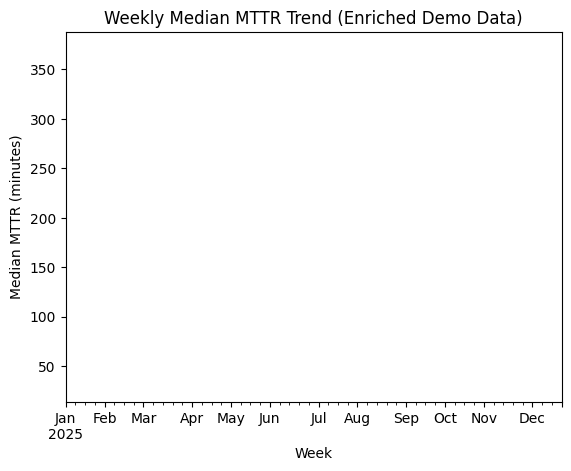

In [6]:
plt.figure()
weekly = df.set_index("detected_at")["t_detect_to_resolution_min"].resample("W").median()
weekly.plot()
plt.xlabel("Week")
plt.ylabel("Median MTTR (minutes)")
plt.title("Weekly Median MTTR Trend (Enriched Demo Data)")
plt.show()


In [ ]:
### “This analysis measures 2025 SLA compliance by supplier using an impact-weighted approach, ensuring that service-affecting incidents influence results more than low-impact volume. 
# By visualising monthly compliance, trends, and breach impact, it highlights where supplier performance creates the greatest operational risk to London transport services and supports targeted intervention.”


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
import numpy as np

suppliers = ["Siemens", "Thales", "Hitachi Rail", "Alstom"]

# Assign suppliers realistically (weighted if desired)
df["supplier"] = np.random.choice(
    suppliers,
    size=len(df),
    p=[0.30, 0.30, 0.20, 0.20]  # Siemens/Thales slightly more common
)

In [17]:

# Inputs you must set
SLA_MINUTES = 360  # example: 6 hours end-to-end
YEAR = 2025
TOP_SUPPLIERS = 6  # keep charts readable

# df must exist already
# df = pd.read_csv("incidents.csv")
df = df.copy()

# Ensure datetime
df["detected_at"] = pd.to_datetime(df["detected_at"], errors="coerce", utc=True)

# Filter to 2025 only
df = df[df["detected_at"].dt.year == YEAR].copy()



# Basic required columns checks (fail fast with a clear error)
required = {"supplier", "detected_at", "t_detect_to_resolution_min"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Define SLA met/breached
df["sla_met"] = df["t_detect_to_resolution_min"] <= SLA_MINUTES

# Impact weighting (TfL-style)
# Preferred: a real business impact score (e.g., passenger disruption minutes, safety impact, revenue impact)
# If you already have one, name it "impact_score" and this will use it.
if "impact_score" not in df.columns:
    # Fallback: derive from severity (edit mapping to match TfL taxonomy)
    sev_map = {"Low": 1, "Medium": 3, "High": 8, "Critical": 13}
    if "severity" in df.columns:
        df["impact_score"] = df["severity"].map(sev_map).fillna(3).astype(float)
    else:
        # Last-resort default (all incidents equal impact)
        df["impact_score"] = 1.0

# OPTIONAL: strengthen TfL realism by amplifying specific categories (edit as needed)
# Example: incidents affecting signalling, comms, or fare systems may carry higher operational risk.
if "category" in df.columns:
    cat_multiplier = {
        "Ransomware": 2.0,
        "Data Exfiltration": 1.8,
        "Malware": 1.4,
        "Phishing": 1.1,
        "False Alert": 0.5,
    }
    df["impact_score"] = df["impact_score"] * df["category"].map(cat_multiplier).fillna(1.0)

In [ ]:
# Month bucket (timezone-safe: convert to London then use month-start)


In [19]:
df["detected_at"] = pd.to_datetime(df["detected_at"], utc=True, errors="coerce")


In [20]:
dt_london = df["detected_at"].dt.tz_convert("Europe/London")

df["month"] = pd.to_datetime(
    dict(year=dt_london.dt.year, month=dt_london.dt.month, day=1),
    utc=True
).dt.tz_convert("Europe/London")


In [16]:
### *  We bucket incidents by London month using timezone-aware truncation rather than period conversion, 
# so reporting aligns with UK operating hours and avoids loss of timezone context

In [24]:
df["weighted_met"] = df["impact_score"] * df["sla_met"].astype(int)
df["breach_impact"] = df["impact_score"] * (~df["sla_met"]).astype(int)


In [25]:
monthly_overall = (
    df.groupby("month", as_index=False)
      .agg(
          weighted_met=("weighted_met", "sum"),
          total_impact=("impact_score", "sum"),
          overall_breach_impact=("breach_impact", "sum"),
      )
)

monthly_overall["overall_weighted_compliance"] = (
    monthly_overall["weighted_met"] /
    monthly_overall["total_impact"].replace(0, np.nan)
)


<Figure size 640x480 with 0 Axes>

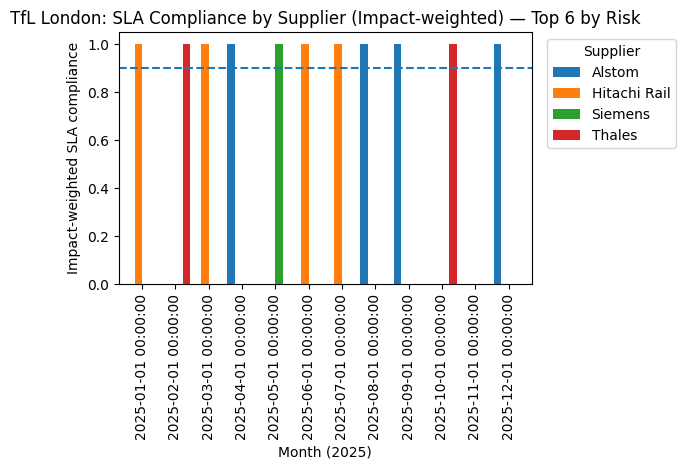

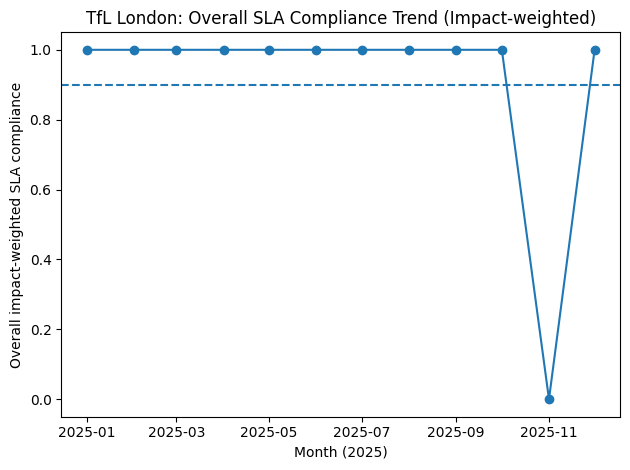

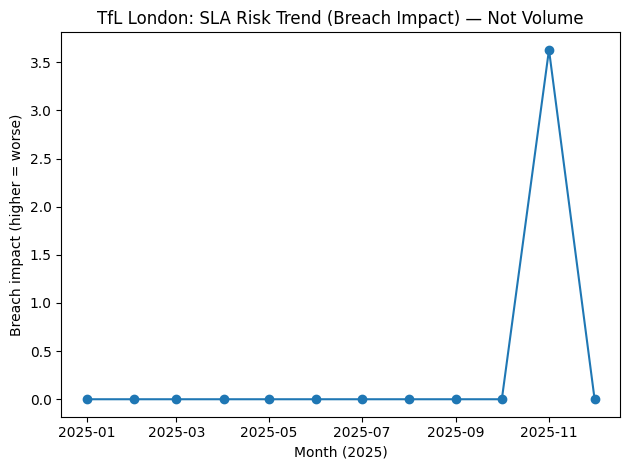


=== Suppliers ranked by SLA breach IMPACT (TfL risk view) ===
       supplier  breach_impact  total_impact  avg_weighted_compliance  \
1  Hitachi Rail           3.63         59.92                      0.8   
0        Alstom           0.00         29.81                      1.0   
2       Siemens           0.00          9.72                      1.0   
3        Thales           0.00         35.63                      1.0   

   breach_impact_share  
1                  1.0  
0                  0.0  
2                  0.0  
3                  0.0  


In [33]:

# Monthly buckets
london = df["detected_at"].dt.tz_convert("Europe/London")

df["month"] = pd.to_datetime(
    dict(year=london.dt.year, month=london.dt.month, day=1),
    utc=True
).dt.tz_convert("Europe/London")


# Impact-weighted compliance and risk

# Rank suppliers by TOTAL breach impact across the year (impact, not volume)
supplier_rank = (
    g.groupby("supplier")["breach_impact"]
     .sum()
     .sort_values(ascending=False)
)

top_suppliers = supplier_rank.head(TOP_SUPPLIERS).index.tolist()

# Pivot for plotting
plot_df = g[g["supplier"].isin(top_suppliers)].copy()

# Ensure all months appear (even if a supplier has no incidents that month)
all_months = pd.date_range(f"{YEAR}-01-01", f"{YEAR}-12-01", freq="MS")
idx = pd.MultiIndex.from_product([all_months, top_suppliers], names=["month", "supplier"])
plot_df = (
    plot_df.set_index(["month", "supplier"])
           .reindex(idx)
           .reset_index()
)

# If no data for a supplier-month, leave NaN compliance; set risk to 0
plot_df["breach_impact"] = plot_df["breach_impact"].fillna(0)
plot_df["weighted_compliance"] = plot_df["weighted_compliance"]

# Chart 1: Monthly SLA compliance by supplier (impact-weighted)
comp_pivot = plot_df.pivot(index="month", columns="supplier", values="weighted_compliance")

plt.figure()
comp_pivot.plot(kind="bar", width=0.9)
plt.axhline(0.90, linestyle="--")  # example compliance target line = 90%
plt.ylabel("Impact-weighted SLA compliance")
plt.xlabel("Month (2025)")
plt.title(f"TfL London: SLA Compliance by Supplier (Impact-weighted) — Top {TOP_SUPPLIERS} by Risk")
plt.legend(title="Supplier", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()




# Chart 2: Overall SLA trend (impact-weighted) + risk trend
df["weighted_met"] = df["impact_score"] * df["sla_met"].astype(int)
df["breach_impact"] = df["impact_score"] * (~df["sla_met"]).astype(int)


plt.figure()
plt.plot(monthly_overall["month"], monthly_overall["overall_weighted_compliance"], marker="o")
plt.axhline(0.90, linestyle="--")
plt.ylabel("Overall impact-weighted SLA compliance")
plt.xlabel("Month (2025)")
plt.title("TfL London: Overall SLA Compliance Trend (Impact-weighted)")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(monthly_overall["month"], monthly_overall["overall_breach_impact"], marker="o")
plt.ylabel("Breach impact (higher = worse)")
plt.xlabel("Month (2025)")
plt.title("TfL London: SLA Risk Trend (Breach Impact) — Not Volume")
plt.tight_layout()
plt.show()


# Output: Risk-focused supplier summary (impact, not count)
risk_summary = (
    g.groupby("supplier", as_index=False)
     .agg(
         breach_impact=("breach_impact", "sum"),
         total_impact=("total_impact", "sum"),
         avg_weighted_compliance=("weighted_compliance", "mean")
     )
)
risk_summary["breach_impact_share"] = risk_summary["breach_impact"] / risk_summary["breach_impact"].sum()
risk_summary = risk_summary.sort_values("breach_impact", ascending=False)

print("\n=== Suppliers ranked by SLA breach IMPACT (TfL risk view) ===")
print(risk_summary.head(15).round(3))


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

In [38]:
monthly_supplier = g[[
    "month",
    "supplier",
    "weighted_compliance",
    "breach_impact",
    "total_impact"
]].copy()


In [39]:
print(g.columns)


Index(['month', 'supplier', 'weighted_compliance', 'breach_impact',
       'total_impact'],
      dtype='object')


In [40]:
mat = (
    monthly_supplier
      .pivot(index="supplier", columns="month", values="weighted_compliance")
      .sort_index()
)


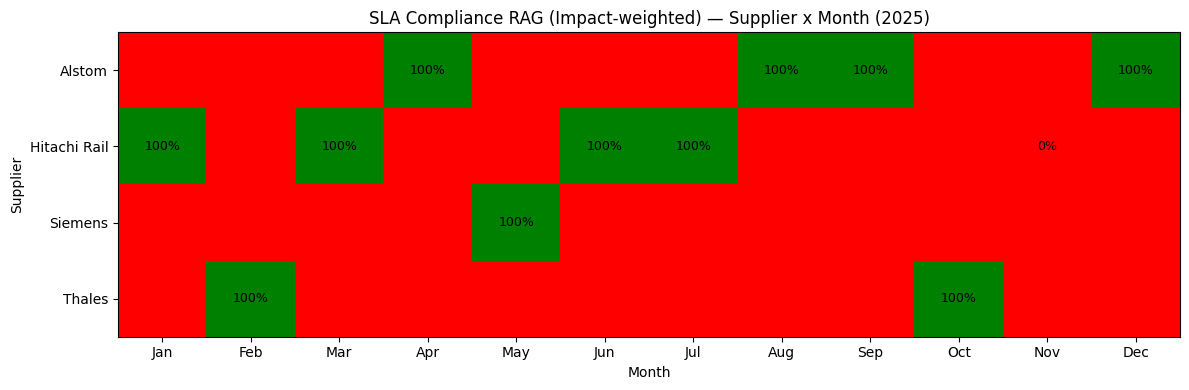

In [41]:

# Inputs
GREEN = 0.95
AMBER = 0.90

# monthly_supplier must exist with columns: month, supplier, weighted_compliance
# Example: monthly_supplier = g[["month","supplier","weighted_compliance"]].copy()

# Pivot to matrix
mat = monthly_supplier.pivot(index="supplier", columns="month", values="weighted_compliance").sort_index()

# Convert compliance to RAG codes: 2=Green, 1=Amber, 0=Red
rag = np.where(mat.values >= GREEN, 2,
      np.where(mat.values >= AMBER, 1, 0))

# Plot
plt.figure(figsize=(12, 4))
cmap = plt.matplotlib.colors.ListedColormap(["red", "orange", "green"])
plt.imshow(rag, aspect="auto", cmap=cmap, vmin=0, vmax=2)

plt.yticks(range(mat.shape[0]), mat.index)
plt.xticks(range(mat.shape[1]), [pd.to_datetime(c).strftime("%b") for c in mat.columns], rotation=0)

plt.title("SLA Compliance RAG (Impact-weighted) — Supplier x Month (2025)")
plt.xlabel("Month")
plt.ylabel("Supplier")

# Optional: annotate with % values
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        val = mat.values[i, j]
        if pd.notna(val):
            plt.text(j, i, f"{val:.0%}", ha="center", va="center", color="black", fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
##The RAG view shows impact-weighted SLA compliance by supplier across the year, highlighting persistent risk areas, recovery patterns, and where performance volatility may require governance attention.


In [ ]:
### Seaborn version (most professional looking)

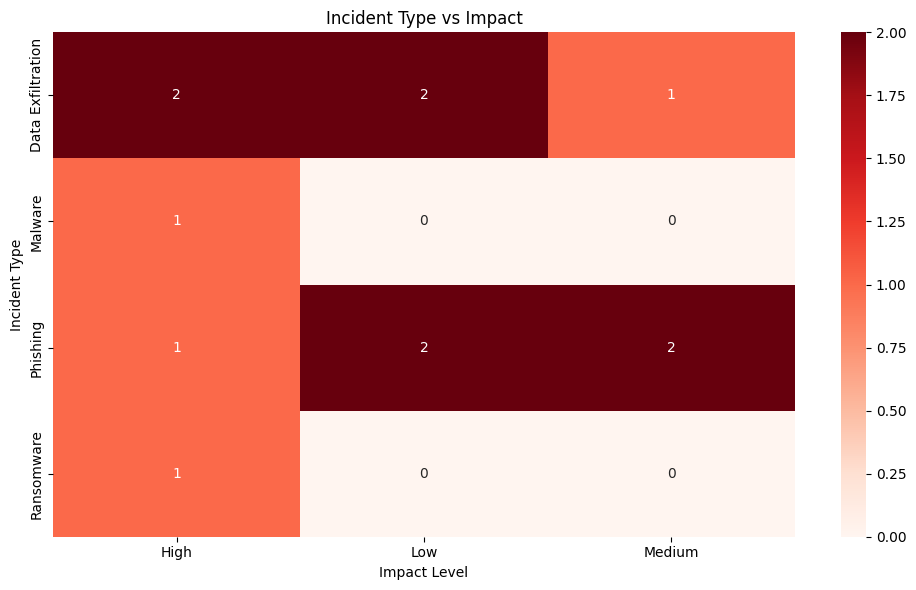

In [42]:

# Crosstab of incident type vs severity
heat = pd.crosstab(df["category"], df["severity"])

plt.figure(figsize=(10, 6))
sns.heatmap(heat, annot=True, fmt="d", cmap="Reds")

plt.title("Incident Type vs Impact")
plt.xlabel("Impact Level")
plt.ylabel("Incident Type")
plt.tight_layout()
plt.show()


In [ ]:
### If you want impact-weighted (stronger)

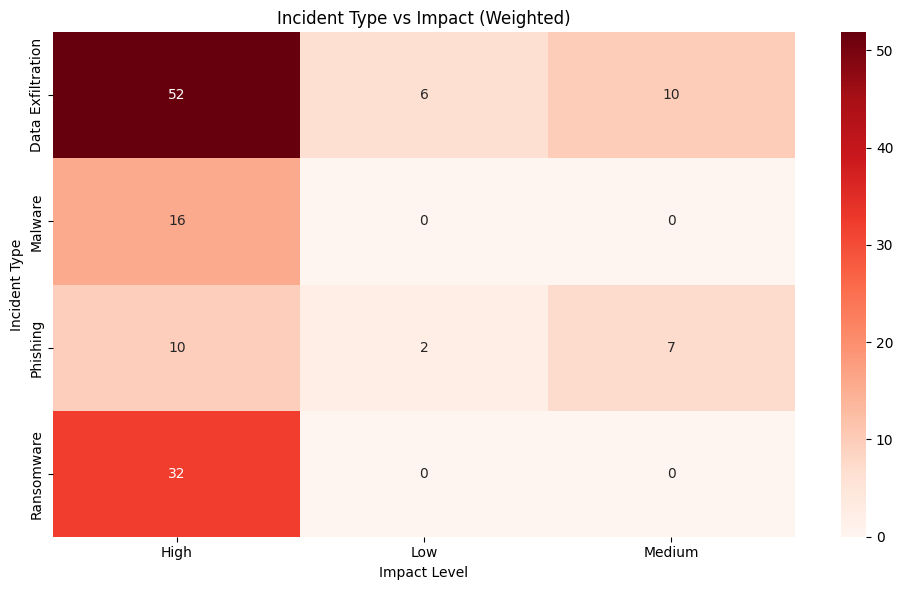

In [43]:
heat = pd.pivot_table(
    df,
    index="category",
    columns="severity",
    values="impact_score",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(10, 6))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="Reds")

plt.title("Incident Type vs Impact (Weighted)")
plt.xlabel("Impact Level")
plt.ylabel("Incident Type")
plt.tight_layout()
plt.show()


In [ ]:
### Matplotlib alternative (simpler, fewer dependencies)

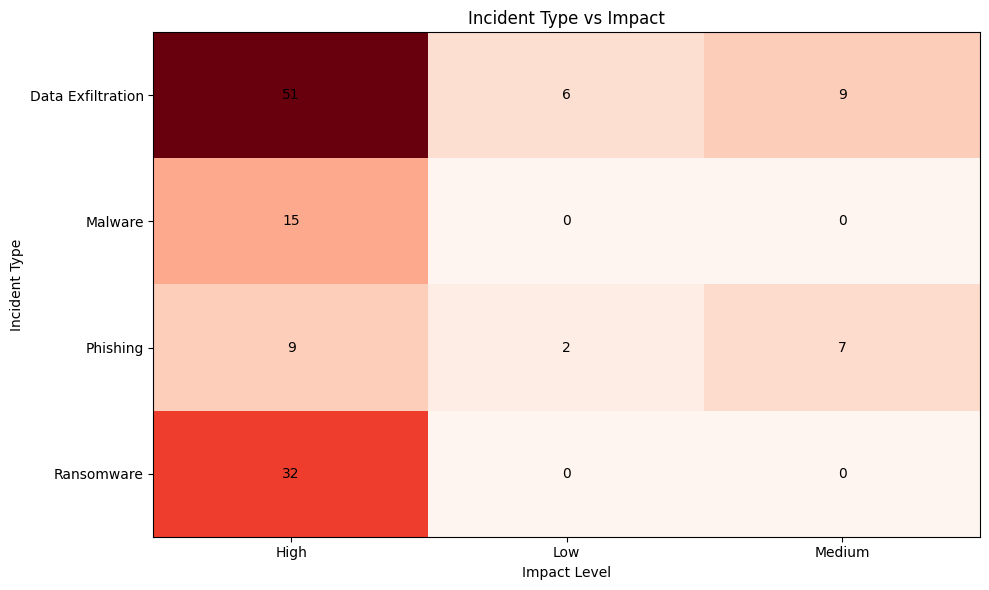

In [44]:
plt.figure(figsize=(10, 6))
plt.imshow(heat, aspect="auto", cmap="Reds")

plt.xticks(range(len(heat.columns)), heat.columns)
plt.yticks(range(len(heat.index)), heat.index)

for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        plt.text(j, i, int(heat.iloc[i, j]), ha="center", va="center")

plt.title("Incident Type vs Impact")
plt.xlabel("Impact Level")
plt.ylabel("Incident Type")
plt.tight_layout()
plt.show()
